In [1]:
# ============================================================
# PHASE 3.2 — MULTIMODAL ERROR + MODALITY CONTRIBUTION ANALYSIS
# 3.2A Error comparison
# 3.2B Block permutation importance
# 3.2C Interpretable LR coefficient analysis
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

In [2]:
# ============================================================
# PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE3_DATA_DIR = PHASE3_DIR / "shared_dataset"
PHASE3_FEATURE_DIR = PHASE3_DIR / "features"

# This should match your Phase 3.1 light folder
PHASE3_1_DIR = PHASE3_DIR / "phase3_1_modelling_light"
PHASE3_1_RESULT_DIR = PHASE3_1_DIR / "results"
PHASE3_1_MODEL_DIR = PHASE3_1_DIR / "models"

PHASE3_2_DIR = PHASE3_DIR / "phase3_2_error_modality_contribution"
RESULT_DIR = PHASE3_2_DIR / "results"
FIGURE_DIR = PHASE3_2_DIR / "figures"
REPORT_DIR = PHASE3_2_DIR / "reports"

for folder in [PHASE3_2_DIR, RESULT_DIR, FIGURE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 3.2 output:", PHASE3_2_DIR)

Mounted at /content/drive
Phase 3.2 output: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution


In [3]:
# ============================================================
# LOAD SHARED TEST DATA
# ============================================================

test_meta = pd.read_csv(PHASE3_DATA_DIR / "test_multimodal_metadata_v1.csv")
y_test = np.load(PHASE3_DATA_DIR / "y_test_multimodal_v1.npy")

X_test_protein = np.load(PHASE3_FEATURE_DIR / "X_test_protein_protbert_sw_v1.npy")
X_test_combined = np.load(PHASE3_FEATURE_DIR / "X_test_combined_protein_genomic_v1.npy")

# For permutation importance, we also need validation optionally.
val_meta = pd.read_csv(PHASE3_DATA_DIR / "val_multimodal_metadata_v1.csv")
y_val = np.load(PHASE3_DATA_DIR / "y_val_multimodal_v1.npy")

X_val_combined = np.load(PHASE3_FEATURE_DIR / "X_val_combined_protein_genomic_v1.npy")

print("Test meta:", test_meta.shape)
print("y_test:", y_test.shape)
print("X_test_protein:", X_test_protein.shape)
print("X_test_combined:", X_test_combined.shape)

print("\nValidation:")
print("val_meta:", val_meta.shape)
print("y_val:", y_val.shape)
print("X_val_combined:", X_val_combined.shape)

print("\nTest label counts:")
print(pd.Series(y_test).value_counts().sort_index())

assert X_test_protein.shape[0] == len(y_test)
assert X_test_combined.shape[0] == len(y_test)
assert X_test_combined.shape[1] == 1380

Test meta: (271, 12)
y_test: (271,)
X_test_protein: (271, 1024)
X_test_combined: (271, 1380)

Validation:
val_meta: (271, 12)
y_val: (271,)
X_val_combined: (271, 1380)

Test label counts:
0    136
1    135
Name: count, dtype: int64


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_positive_class_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_from_score(y_true, y_score, threshold=0.5, model_name="model"):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def evaluate_model(model, X, y_true, threshold=0.5, model_name="model"):
    y_score = get_positive_class_score(model, X)
    return evaluate_from_score(
        y_true=y_true,
        y_score=y_score,
        threshold=threshold,
        model_name=model_name
    )


def classify_correctness(y_true, y_pred):
    return y_true == y_pred


def assign_error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 0:
        return "TN"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 1 and y_pred == 0:
        return "FN"
    return "UNKNOWN"


def safe_name(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
        .replace("/", "_")
    )

In [5]:
# ============================================================
# LOAD PHASE 3.1 MODELS
# ============================================================

# Expected model paths from previous Phase 3.1 light code
protein_svm_path = PHASE3_1_MODEL_DIR / "phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl"
combined_svm_path = PHASE3_1_MODEL_DIR / "phase3_1_combined_proteinplusgenomic_svm_rbf_light.pkl"
combined_lr_path = PHASE3_1_MODEL_DIR / "phase3_1_combined_proteinplusgenomic_logistic_regression_light.pkl"

print("Protein SVM exists:", protein_svm_path.exists(), protein_svm_path)
print("Combined SVM exists:", combined_svm_path.exists(), combined_svm_path)
print("Combined LR exists:", combined_lr_path.exists(), combined_lr_path)

Protein SVM exists: True /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_protein_only_protbert_sw_svm_rbf_light.pkl
Combined SVM exists: True /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_combined_proteinplusgenomic_svm_rbf_light.pkl
Combined LR exists: True /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_1_modelling_light/models/phase3_1_combined_proteinplusgenomic_logistic_regression_light.pkl


In [6]:
# ============================================================
# LOAD MODELS
# ============================================================

assert protein_svm_path.exists(), "Protein SVM model file not found. Check model filename."
assert combined_svm_path.exists(), "Combined SVM model file not found. Check model filename."

protein_svm_model = joblib.load(protein_svm_path)
combined_svm_model = joblib.load(combined_svm_path)

combined_lr_model = None
if combined_lr_path.exists():
    combined_lr_model = joblib.load(combined_lr_path)

print("Loaded protein_svm_model:", type(protein_svm_model))
print("Loaded combined_svm_model:", type(combined_svm_model))
print("Loaded combined_lr_model:", type(combined_lr_model) if combined_lr_model is not None else None)

Loaded protein_svm_model: <class 'sklearn.pipeline.Pipeline'>
Loaded combined_svm_model: <class 'sklearn.pipeline.Pipeline'>
Loaded combined_lr_model: <class 'sklearn.pipeline.Pipeline'>


In [7]:
# ============================================================
# CONFIRM TEST METRICS
# ============================================================

protein_svm_test_score = get_positive_class_score(protein_svm_model, X_test_protein)
combined_svm_test_score = get_positive_class_score(combined_svm_model, X_test_combined)

protein_svm_test_pred = (protein_svm_test_score >= 0.5).astype(int)
combined_svm_test_pred = (combined_svm_test_score >= 0.5).astype(int)

protein_svm_metrics = evaluate_from_score(
    y_true=y_test,
    y_score=protein_svm_test_score,
    threshold=0.5,
    model_name="Protein-only ProtBERT-SW SVM RBF"
)

combined_svm_metrics = evaluate_from_score(
    y_true=y_test,
    y_score=combined_svm_test_score,
    threshold=0.5,
    model_name="Combined Protein+Genomic SVM RBF"
)

phase3_2_metric_check_df = pd.DataFrame([
    protein_svm_metrics,
    combined_svm_metrics
])

display(phase3_2_metric_check_df)

phase3_2_metric_check_df.to_csv(
    RESULT_DIR / "phase3_2_metric_check_protein_vs_combined_svm.csv",
    index=False
)

,model,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Protein-only ProtBERT-SW SVM RBF,0.5,0.660517,0.652482,0.681481,0.639706,0.666667,0.727397,0.743341,0.321450,87,49,43,92
1,Combined Protein+Genomic SVM RBF,0.5,0.671587,0.682540,0.637037,0.705882,0.659004,0.728976,0.757253,0.343763,96,40,49,86


In [8]:
# ============================================================
# PHASE 3.2A — ERROR COMPARISON TABLE
# Protein-only SVM vs Combined SVM
# ============================================================

comparison_df = test_meta[[
    "gene_id",
    "gene_symbol",
    "label"
]].copy()

comparison_df["true_label"] = y_test

comparison_df["protein_svm_score"] = protein_svm_test_score
comparison_df["combined_svm_score"] = combined_svm_test_score

comparison_df["protein_svm_pred"] = protein_svm_test_pred
comparison_df["combined_svm_pred"] = combined_svm_test_pred

comparison_df["protein_correct"] = comparison_df["protein_svm_pred"] == comparison_df["true_label"]
comparison_df["combined_correct"] = comparison_df["combined_svm_pred"] == comparison_df["true_label"]

comparison_df["protein_error_type"] = comparison_df.apply(
    lambda row: assign_error_type(row["true_label"], row["protein_svm_pred"]),
    axis=1
)

comparison_df["combined_error_type"] = comparison_df.apply(
    lambda row: assign_error_type(row["true_label"], row["combined_svm_pred"]),
    axis=1
)

comparison_df["score_delta_combined_minus_protein"] = (
    comparison_df["combined_svm_score"] - comparison_df["protein_svm_score"]
)

def assign_integration_group(row):
    if row["protein_correct"] and row["combined_correct"]:
        return "both_correct"
    if (not row["protein_correct"]) and (not row["combined_correct"]):
        return "both_wrong"
    if (not row["protein_correct"]) and row["combined_correct"]:
        return "combined_correct_protein_wrong"
    if row["protein_correct"] and (not row["combined_correct"]):
        return "protein_correct_combined_wrong"
    return "unknown"

comparison_df["integration_error_group"] = comparison_df.apply(
    assign_integration_group,
    axis=1
)

display(comparison_df.head())

comparison_df.to_csv(
    RESULT_DIR / "phase3_2A_protein_vs_combined_svm_test_prediction_comparison.csv",
    index=False
)

,gene_id,gene_symbol,label,true_label,protein_svm_score,combined_svm_score,protein_svm_pred,combined_svm_pred,protein_correct,combined_correct,protein_error_type,combined_error_type,score_delta_combined_minus_protein,integration_error_group
0,ENSG00000122971,ACADS,1,1,0.719627,0.750810,1,1,True,True,TP,TP,0.031183,both_correct
1,ENSG00000162104,ADCY9,1,1,0.680303,0.756812,1,1,True,True,TP,TP,0.076509,both_correct
2,ENSG00000123146,ADGRE5,0,0,0.554474,0.532796,1,1,False,False,FP,FP,-0.021678,both_wrong
3,ENSG00000172594,SMPDL3A,0,0,0.683032,0.690366,1,1,False,False,FP,FP,0.007335,both_wrong
4,ENSG00000163116,STPG2,0,0,0.237920,0.235603,0,0,True,True,TN,TN,-0.002317,both_correct


In [9]:
# ============================================================
# ERROR GROUP COUNTS
# ============================================================

error_group_counts_df = (
    comparison_df["integration_error_group"]
    .value_counts()
    .reset_index()
)

error_group_counts_df.columns = ["integration_error_group", "n"]
error_group_counts_df["percentage"] = error_group_counts_df["n"] / len(comparison_df) * 100

display(error_group_counts_df)

error_group_counts_df.to_csv(
    RESULT_DIR / "phase3_2A_error_group_counts.csv",
    index=False
)

,integration_error_group,n,percentage
0,both_correct,164,60.516605
1,both_wrong,74,27.306273
2,combined_correct_protein_wrong,18,6.642066
3,protein_correct_combined_wrong,15,5.535055


In [10]:
# ============================================================
# ERROR GROUP BY TRUE LABEL
# ============================================================

error_group_by_label_df = pd.crosstab(
    comparison_df["integration_error_group"],
    comparison_df["true_label"],
    margins=True
)

display(error_group_by_label_df)

error_group_by_label_df.to_csv(
    RESULT_DIR / "phase3_2A_error_group_by_true_label.csv"
)

true_label,0,1,All
integration_error_group,,,
both_correct,81,83,164
both_wrong,34,40,74
combined_correct_protein_wrong,15,3,18
protein_correct_combined_wrong,6,9,15
All,136,135,271


In [11]:
# ============================================================
# CONFUSION MATRIX COMPARISON
# ============================================================

protein_cm = confusion_matrix(y_test, protein_svm_test_pred)
combined_cm = confusion_matrix(y_test, combined_svm_test_pred)

protein_cm_df = pd.DataFrame(
    protein_cm,
    index=["Actual_0_Background", "Actual_1_T2D"],
    columns=["Pred_0_Background", "Pred_1_T2D"]
)

combined_cm_df = pd.DataFrame(
    combined_cm,
    index=["Actual_0_Background", "Actual_1_T2D"],
    columns=["Pred_0_Background", "Pred_1_T2D"]
)

print("Protein-only SVM confusion matrix")
display(protein_cm_df)

print("Combined SVM confusion matrix")
display(combined_cm_df)

protein_cm_df.to_csv(RESULT_DIR / "phase3_2A_confusion_matrix_protein_svm.csv")
combined_cm_df.to_csv(RESULT_DIR / "phase3_2A_confusion_matrix_combined_svm.csv")

Protein-only SVM confusion matrix


,Pred_0_Background,Pred_1_T2D
Actual_0_Background,87,49
Actual_1_T2D,43,92


Combined SVM confusion matrix


,Pred_0_Background,Pred_1_T2D
Actual_0_Background,96,40
Actual_1_T2D,49,86


In [12]:
# ============================================================
# EXPORT RESCUED AND LOST GENES
# ============================================================

combined_rescued_df = comparison_df[
    comparison_df["integration_error_group"] == "combined_correct_protein_wrong"
].copy()

protein_lost_df = comparison_df[
    comparison_df["integration_error_group"] == "protein_correct_combined_wrong"
].copy()

both_correct_df = comparison_df[
    comparison_df["integration_error_group"] == "both_correct"
].copy()

both_wrong_df = comparison_df[
    comparison_df["integration_error_group"] == "both_wrong"
].copy()

# Sort rescued: strongest combined confidence
combined_rescued_df = combined_rescued_df.sort_values(
    by=["true_label", "combined_svm_score"],
    ascending=[False, False]
)

# Sort lost: strongest protein confidence
protein_lost_df = protein_lost_df.sort_values(
    by=["true_label", "protein_svm_score"],
    ascending=[False, False]
)

print("Combined rescued genes:", combined_rescued_df.shape)
display(combined_rescued_df.head(30))

print("Protein-correct but lost after integration:", protein_lost_df.shape)
display(protein_lost_df.head(30))

combined_rescued_df.to_csv(
    RESULT_DIR / "phase3_2A_combined_correct_protein_wrong_rescued_genes.csv",
    index=False
)

protein_lost_df.to_csv(
    RESULT_DIR / "phase3_2A_protein_correct_combined_wrong_lost_genes.csv",
    index=False
)

both_correct_df.to_csv(
    RESULT_DIR / "phase3_2A_both_correct_genes.csv",
    index=False
)

both_wrong_df.to_csv(
    RESULT_DIR / "phase3_2A_both_wrong_genes.csv",
    index=False
)

Combined rescued genes: (18, 14)


,gene_id,gene_symbol,label,true_label,protein_svm_score,combined_svm_score,protein_svm_pred,combined_svm_pred,protein_correct,combined_correct,protein_error_type,combined_error_type,score_delta_combined_minus_protein,integration_error_group
115,ENSG00000151883,PARP8,1,1,0.457089,0.540746,0,1,False,True,FN,TP,0.083657,combined_correct_protein_wrong
112,ENSG00000006071,ABCC8,1,1,0.469028,0.522492,0,1,False,True,FN,TP,0.053464,combined_correct_protein_wrong
29,ENSG00000134640,MTNR1B,1,1,0.494592,0.500000,0,1,False,True,FN,TP,0.005408,combined_correct_protein_wrong
76,ENSG00000103978,TMEM87A,0,0,0.617864,0.494235,1,0,False,True,FP,TN,-0.123629,combined_correct_protein_wrong
54,ENSG00000122550,KLHL7,0,0,0.714343,0.491790,1,0,False,True,FP,TN,-0.222553,combined_correct_protein_wrong
229,ENSG00000105738,SIPA1L3,0,0,0.597829,0.486927,1,0,False,True,FP,TN,-0.110902,combined_correct_protein_wrong
94,ENSG00000077327,SPAG6,0,0,0.556301,0.476395,1,0,False,True,FP,TN,-0.079906,combined_correct_protein_wrong
99,ENSG00000197530,MIB2,0,0,0.576509,0.463581,1,0,False,True,FP,TN,-0.112928,combined_correct_protein_wrong
107,ENSG00000154832,CXXC1,0,0,0.607166,0.460217,1,0,False,True,FP,TN,-0.146949,combined_correct_protein_wrong
6,ENSG00000173320,STOX2,0,0,0.569132,0.452565,1,0,False,True,FP,TN,-0.116567,combined_correct_protein_wrong


Protein-correct but lost after integration: (15, 14)


,gene_id,gene_symbol,label,true_label,protein_svm_score,combined_svm_score,protein_svm_pred,combined_svm_pred,protein_correct,combined_correct,protein_error_type,combined_error_type,score_delta_combined_minus_protein,integration_error_group
10,ENSG00000156219,ART3,1,1,0.619308,0.352695,1,0,True,False,TP,FN,-0.266613,protein_correct_combined_wrong
24,ENSG00000101391,CDK5RAP1,1,1,0.607145,0.494782,1,0,True,False,TP,FN,-0.112363,protein_correct_combined_wrong
113,ENSG00000134480,CCNH,1,1,0.585092,0.359140,1,0,True,False,TP,FN,-0.225952,protein_correct_combined_wrong
53,ENSG00000241878,PISD,1,1,0.578919,0.441545,1,0,True,False,TP,FN,-0.137375,protein_correct_combined_wrong
209,ENSG00000185345,PRKN,1,1,0.568179,0.441144,1,0,True,False,TP,FN,-0.127035,protein_correct_combined_wrong
153,ENSG00000147684,NDUFB9,1,1,0.531210,0.461754,1,0,True,False,TP,FN,-0.069456,protein_correct_combined_wrong
127,ENSG00000128805,ARHGAP22,1,1,0.529745,0.435654,1,0,True,False,TP,FN,-0.094091,protein_correct_combined_wrong
188,ENSG00000165623,UCMA,1,1,0.517002,0.492378,1,0,True,False,TP,FN,-0.024624,protein_correct_combined_wrong
83,ENSG00000131778,CHD1L,1,1,0.507651,0.491878,1,0,True,False,TP,FN,-0.015772,protein_correct_combined_wrong
12,ENSG00000157212,PAXIP1,0,0,0.487344,0.723585,0,1,True,False,TN,FP,0.236241,protein_correct_combined_wrong


In [13]:
# ============================================================
# SCORE DELTA ANALYSIS
# ============================================================

score_delta_summary_df = comparison_df.groupby("integration_error_group").agg(
    n=("gene_id", "count"),
    mean_protein_score=("protein_svm_score", "mean"),
    mean_combined_score=("combined_svm_score", "mean"),
    mean_delta_combined_minus_protein=("score_delta_combined_minus_protein", "mean"),
    median_delta_combined_minus_protein=("score_delta_combined_minus_protein", "median")
).reset_index().sort_values("n", ascending=False)

display(score_delta_summary_df)

score_delta_summary_df.to_csv(
    RESULT_DIR / "phase3_2A_score_delta_summary_by_error_group.csv",
    index=False
)

,integration_error_group,n,mean_protein_score,mean_combined_score,mean_delta_combined_minus_protein,median_delta_combined_minus_protein
0,both_correct,164,0.498823,0.501418,0.002595,-0.001121
1,both_wrong,74,0.465782,0.471258,0.005476,0.004681
2,combined_correct_protein_wrong,18,0.558602,0.447129,-0.111474,-0.114755
3,protein_correct_combined_wrong,15,0.522147,0.495538,-0.026609,-0.024624


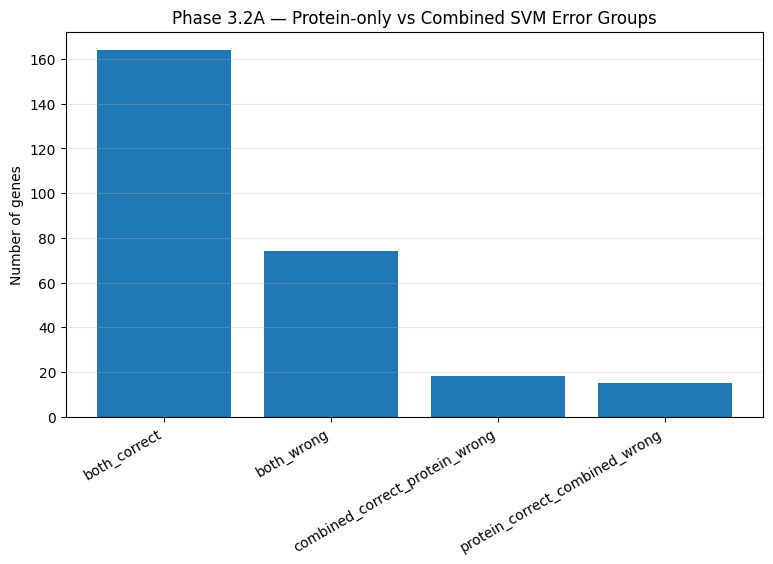

Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/figures/phase3_2A_error_group_counts.png


In [14]:
# ============================================================
# PLOT ERROR GROUP COUNTS
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    error_group_counts_df["integration_error_group"],
    error_group_counts_df["n"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of genes")
plt.title("Phase 3.2A — Protein-only vs Combined SVM Error Groups")
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase3_2A_error_group_counts.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [15]:
# ============================================================
# PHASE 3.2B — BLOCK PERMUTATION IMPORTANCE
# ============================================================

PROTEIN_DIM = 1024
GENOMIC_DIM = 356
COMBINED_DIM = PROTEIN_DIM + GENOMIC_DIM

assert X_test_combined.shape[1] == COMBINED_DIM

protein_block_slice = slice(0, PROTEIN_DIM)
genomic_block_slice = slice(PROTEIN_DIM, COMBINED_DIM)

print("Protein block:", protein_block_slice)
print("Genomic block:", genomic_block_slice)

Protein block: slice(0, 1024, None)
Genomic block: slice(1024, 1380, None)


In [16]:
def permute_block(X, block_slice, random_state):
    """
    Permute a block of columns row-wise.
    This breaks the relationship between that modality block and label,
    while preserving marginal distribution of the block.
    """
    rng = np.random.default_rng(random_state)

    X_perm = X.copy()

    permuted_row_indices = rng.permutation(X_perm.shape[0])

    X_perm[:, block_slice] = X_perm[permuted_row_indices, block_slice]

    return X_perm


def evaluate_combined_svm_on_matrix(X_matrix, y_true, threshold=0.5, model_name="Combined SVM"):
    y_score = get_positive_class_score(combined_svm_model, X_matrix)

    metrics = evaluate_from_score(
        y_true=y_true,
        y_score=y_score,
        threshold=threshold,
        model_name=model_name
    )

    return metrics

In [17]:
# ============================================================
# BASELINE COMBINED SVM PERFORMANCE
# ============================================================

baseline_combined_metrics = evaluate_combined_svm_on_matrix(
    X_matrix=X_test_combined,
    y_true=y_test,
    threshold=0.5,
    model_name="Combined SVM baseline"
)

baseline_combined_metrics_df = pd.DataFrame([baseline_combined_metrics])

display(baseline_combined_metrics_df)

baseline_combined_metrics_df.to_csv(
    RESULT_DIR / "phase3_2B_combined_svm_baseline_metrics.csv",
    index=False
)

,model,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Combined SVM baseline,0.5,0.671587,0.68254,0.637037,0.705882,0.659004,0.728976,0.757253,0.343763,96,40,49,86


In [18]:
# ============================================================
# RUN BLOCK PERMUTATION IMPORTANCE
# ============================================================

N_REPEATS = 30

permutation_records = []

for repeat_id in range(N_REPEATS):
    random_state = 42 + repeat_id

    # Protein block permutation
    X_perm_protein = permute_block(
        X=X_test_combined,
        block_slice=protein_block_slice,
        random_state=random_state
    )

    protein_perm_metrics = evaluate_combined_svm_on_matrix(
        X_matrix=X_perm_protein,
        y_true=y_test,
        threshold=0.5,
        model_name="Protein block permuted"
    )

    protein_perm_metrics["permuted_block"] = "protein_block"
    protein_perm_metrics["repeat_id"] = repeat_id

    permutation_records.append(protein_perm_metrics)

    # Genomic block permutation
    X_perm_genomic = permute_block(
        X=X_test_combined,
        block_slice=genomic_block_slice,
        random_state=random_state
    )

    genomic_perm_metrics = evaluate_combined_svm_on_matrix(
        X_matrix=X_perm_genomic,
        y_true=y_test,
        threshold=0.5,
        model_name="Genomic block permuted"
    )

    genomic_perm_metrics["permuted_block"] = "genomic_block"
    genomic_perm_metrics["repeat_id"] = repeat_id

    permutation_records.append(genomic_perm_metrics)

block_permutation_df = pd.DataFrame(permutation_records)

# Add drops relative to baseline
for metric in ["roc_auc", "pr_auc", "f1", "mcc", "accuracy"]:
    block_permutation_df[f"{metric}_drop"] = (
        baseline_combined_metrics[metric] - block_permutation_df[metric]
    )

display(block_permutation_df.head())

block_permutation_df.to_csv(
    RESULT_DIR / "phase3_2B_block_permutation_importance_raw.csv",
    index=False
)

,model,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp,permuted_block,repeat_id,roc_auc_drop,pr_auc_drop,f1_drop,mcc_drop,accuracy_drop
0,Protein block permuted,0.5,0.505535,0.503597,0.518519,0.492647,0.510949,0.515359,0.519672,0.011169,67,69,65,70,protein_block,0,0.213617,0.237581,0.148055,0.332594,0.166052
1,Genomic block permuted,0.5,0.678967,0.681818,0.666667,0.691176,0.674157,0.715714,0.731090,0.357960,94,42,45,90,genomic_block,0,0.013263,0.026163,-0.015153,-0.014197,-0.007380
2,Protein block permuted,0.5,0.483395,0.481203,0.474074,0.492647,0.477612,0.496460,0.519793,-0.033284,67,69,71,64,protein_block,1,0.232516,0.237460,0.181392,0.377047,0.188192
3,Genomic block permuted,0.5,0.664207,0.664179,0.659259,0.669118,0.661710,0.733361,0.758339,0.328395,91,45,46,89,genomic_block,1,-0.004385,-0.001086,-0.002706,0.015368,0.007380
4,Protein block permuted,0.5,0.531365,0.528986,0.540741,0.522059,0.534799,0.552914,0.528916,0.062810,71,65,62,73,protein_block,2,0.176062,0.228337,0.124205,0.280953,0.140221


In [19]:
# ============================================================
# SUMMARIZE BLOCK PERMUTATION IMPORTANCE
# ============================================================

summary_records = []

for block_name, group_df in block_permutation_df.groupby("permuted_block"):
    row = {
        "permuted_block": block_name,
        "n_repeats": len(group_df),

        "baseline_roc_auc": baseline_combined_metrics["roc_auc"],
        "baseline_pr_auc": baseline_combined_metrics["pr_auc"],
        "baseline_f1": baseline_combined_metrics["f1"],
        "baseline_mcc": baseline_combined_metrics["mcc"],

        "mean_roc_auc_after_permutation": group_df["roc_auc"].mean(),
        "std_roc_auc_after_permutation": group_df["roc_auc"].std(),
        "mean_roc_auc_drop": group_df["roc_auc_drop"].mean(),
        "std_roc_auc_drop": group_df["roc_auc_drop"].std(),

        "mean_pr_auc_after_permutation": group_df["pr_auc"].mean(),
        "std_pr_auc_after_permutation": group_df["pr_auc"].std(),
        "mean_pr_auc_drop": group_df["pr_auc_drop"].mean(),
        "std_pr_auc_drop": group_df["pr_auc_drop"].std(),

        "mean_f1_after_permutation": group_df["f1"].mean(),
        "std_f1_after_permutation": group_df["f1"].std(),
        "mean_f1_drop": group_df["f1_drop"].mean(),
        "std_f1_drop": group_df["f1_drop"].std(),

        "mean_mcc_after_permutation": group_df["mcc"].mean(),
        "std_mcc_after_permutation": group_df["mcc"].std(),
        "mean_mcc_drop": group_df["mcc_drop"].mean(),
        "std_mcc_drop": group_df["mcc_drop"].std(),
    }

    summary_records.append(row)

block_permutation_summary_df = pd.DataFrame(summary_records).sort_values(
    by="mean_roc_auc_drop",
    ascending=False
)

display(block_permutation_summary_df)

block_permutation_summary_df.to_csv(
    RESULT_DIR / "phase3_2B_block_permutation_importance_summary.csv",
    index=False
)

,permuted_block,n_repeats,baseline_roc_auc,baseline_pr_auc,baseline_f1,baseline_mcc,mean_roc_auc_after_permutation,std_roc_auc_after_permutation,mean_roc_auc_drop,std_roc_auc_drop,mean_pr_auc_after_permutation,std_pr_auc_after_permutation,mean_pr_auc_drop,std_pr_auc_drop,mean_f1_after_permutation,std_f1_after_permutation,mean_f1_drop,std_f1_drop,mean_mcc_after_permutation,std_mcc_after_permutation,mean_mcc_drop,std_mcc_drop
1,protein_block,30,0.728976,0.757253,0.659004,0.343763,0.530081,0.039645,0.198895,0.039645,0.532956,0.031624,0.224297,0.031624,0.511347,0.035914,0.147657,0.035914,0.035364,0.067592,0.308399,0.067592
0,genomic_block,30,0.728976,0.757253,0.659004,0.343763,0.706920,0.015688,0.022056,0.015688,0.717830,0.023151,0.039423,0.023151,0.651617,0.019692,0.007387,0.019692,0.314582,0.038780,0.029181,0.038780


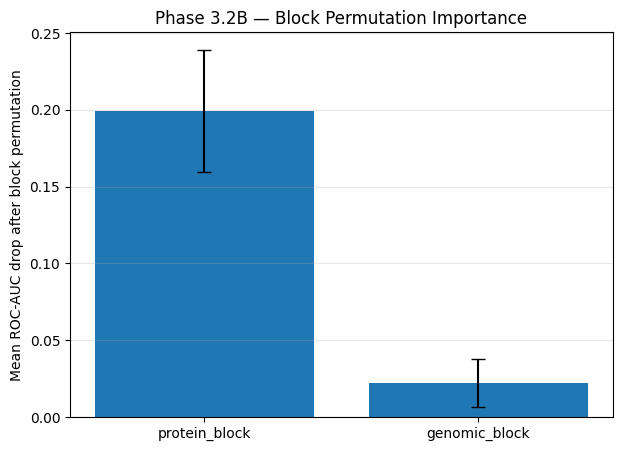

Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/figures/phase3_2B_block_permutation_roc_auc_drop.png


In [20]:
# ============================================================
# PLOT BLOCK IMPORTANCE BY ROC-AUC DROP
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    block_permutation_summary_df["permuted_block"],
    block_permutation_summary_df["mean_roc_auc_drop"],
    yerr=block_permutation_summary_df["std_roc_auc_drop"],
    capsize=5
)

plt.ylabel("Mean ROC-AUC drop after block permutation")
plt.title("Phase 3.2B — Block Permutation Importance")
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase3_2B_block_permutation_roc_auc_drop.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

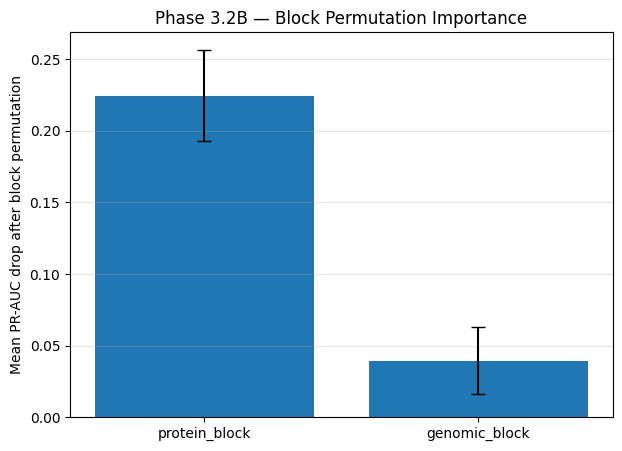

Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/figures/phase3_2B_block_permutation_pr_auc_drop.png


In [21]:
# ============================================================
# PLOT BLOCK IMPORTANCE BY PR-AUC DROP
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    block_permutation_summary_df["permuted_block"],
    block_permutation_summary_df["mean_pr_auc_drop"],
    yerr=block_permutation_summary_df["std_pr_auc_drop"],
    capsize=5
)

plt.ylabel("Mean PR-AUC drop after block permutation")
plt.title("Phase 3.2B — Block Permutation Importance")
plt.grid(axis="y", alpha=0.3)

fig_path = FIGURE_DIR / "phase3_2B_block_permutation_pr_auc_drop.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [22]:
# ============================================================
# PHASE 3.2C — LOAD FEATURE NAMES
# ============================================================

feature_name_path = PHASE3_FEATURE_DIR / "phase3_0_feature_names_v1.json"

assert feature_name_path.exists(), "Feature name JSON not found."

with open(feature_name_path, "r") as f:
    feature_name_info = json.load(f)

protein_feature_names = feature_name_info["protein_feature_names"]
genomic_feature_names = feature_name_info["genomic_feature_names"]
combined_feature_names = feature_name_info["combined_feature_names"]

print("Protein features:", len(protein_feature_names))
print("Genomic features:", len(genomic_feature_names))
print("Combined features:", len(combined_feature_names))

assert len(protein_feature_names) == 1024
assert len(genomic_feature_names) == 356
assert len(combined_feature_names) == 1380

Protein features: 1024
Genomic features: 356
Combined features: 1380


In [23]:
# ============================================================
# ANALYZE COMBINED LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

if combined_lr_model is None:
    print("Combined Logistic Regression model not found. Skipping LR coefficient analysis.")
else:
    print("Combined LR pipeline steps:")
    print(combined_lr_model.named_steps.keys())

    lr_model = combined_lr_model.named_steps["model"]

    # Determine selected features after VarianceThreshold
    if "variance" in combined_lr_model.named_steps:
        variance_selector = combined_lr_model.named_steps["variance"]
        selected_mask = variance_selector.get_support()
        selected_features = np.array(combined_feature_names)[selected_mask]
    else:
        selected_features = np.array(combined_feature_names)

    coefficients = lr_model.coef_[0]

    assert len(selected_features) == len(coefficients)

    lr_coef_df = pd.DataFrame({
        "feature": selected_features,
        "coefficient": coefficients
    })

    lr_coef_df["abs_coefficient"] = lr_coef_df["coefficient"].abs()

    def assign_feature_modality(feature_name):
        if feature_name.startswith("protbert_sw_"):
            return "protein"
        return "genomic"

    lr_coef_df["modality"] = lr_coef_df["feature"].apply(assign_feature_modality)

    lr_coef_df = lr_coef_df.sort_values(
        by="abs_coefficient",
        ascending=False
    )

    display(lr_coef_df.head(50))

    lr_coef_df.to_csv(
        RESULT_DIR / "phase3_2C_combined_logistic_regression_coefficients.csv",
        index=False
    )

Combined LR pipeline steps:
dict_keys(['variance', 'scaler', 'model'])


,feature,coefficient,abs_coefficient,modality
1301,k4_GTAG,-0.036489,0.036489,genomic
40,protbert_sw_40,-0.031693,0.031693,protein
418,protbert_sw_418,-0.029148,0.029148,protein
822,protbert_sw_822,0.027779,0.027779,protein
1295,k4_GGTA,-0.027391,0.027391,genomic
1143,k4_ACCA,-0.026827,0.026827,genomic
1345,k4_TCTG,-0.026394,0.026394,genomic
160,protbert_sw_160,-0.026039,0.026039,protein
976,protbert_sw_976,0.025658,0.025658,protein
763,protbert_sw_763,0.025558,0.025558,protein


In [24]:
# ============================================================
# COEFFICIENT CONTRIBUTION BY MODALITY
# ============================================================

if combined_lr_model is not None:
    modality_coef_summary_df = lr_coef_df.groupby("modality").agg(
        n_features=("feature", "count"),
        sum_abs_coefficient=("abs_coefficient", "sum"),
        mean_abs_coefficient=("abs_coefficient", "mean"),
        median_abs_coefficient=("abs_coefficient", "median"),
        max_abs_coefficient=("abs_coefficient", "max")
    ).reset_index()

    modality_coef_summary_df["share_of_total_abs_coefficient"] = (
        modality_coef_summary_df["sum_abs_coefficient"] /
        modality_coef_summary_df["sum_abs_coefficient"].sum()
    )

    display(modality_coef_summary_df)

    modality_coef_summary_df.to_csv(
        RESULT_DIR / "phase3_2C_lr_modality_coefficient_summary.csv",
        index=False
    )

,modality,n_features,sum_abs_coefficient,mean_abs_coefficient,median_abs_coefficient,max_abs_coefficient,share_of_total_abs_coefficient
0,genomic,355,2.773525,0.007813,0.006411,0.036489,0.295401
1,protein,1024,6.615487,0.006460,0.005430,0.031693,0.704599


In [25]:
# ============================================================
# TOP GENOMIC FEATURES FROM COMBINED LR
# ============================================================

if combined_lr_model is not None:
    top_genomic_coef_df = lr_coef_df[
        lr_coef_df["modality"] == "genomic"
    ].sort_values(
        by="abs_coefficient",
        ascending=False
    ).head(50)

    display(top_genomic_coef_df)

    top_genomic_coef_df.to_csv(
        RESULT_DIR / "phase3_2C_top_genomic_features_combined_lr.csv",
        index=False
    )

,feature,coefficient,abs_coefficient,modality
1301,k4_GTAG,-0.036489,0.036489,genomic
1295,k4_GGTA,-0.027391,0.027391,genomic
1143,k4_ACCA,-0.026827,0.026827,genomic
1345,k4_TCTG,-0.026394,0.026394,genomic
1246,k4_CTGT,-0.025098,0.025098,genomic
1211,k4_CCGA,-0.024708,0.024708,genomic
1206,k4_CCAT,-0.024556,0.024556,genomic
1348,k4_TGAC,0.023761,0.023761,genomic
1176,k4_ATCC,-0.023738,0.023738,genomic
1220,k4_CGAC,-0.022881,0.022881,genomic


In [26]:
# ============================================================
# TOP PROTEIN FEATURES FROM COMBINED LR
# ============================================================

if combined_lr_model is not None:
    top_protein_coef_df = lr_coef_df[
        lr_coef_df["modality"] == "protein"
    ].sort_values(
        by="abs_coefficient",
        ascending=False
    ).head(50)

    display(top_protein_coef_df)

    top_protein_coef_df.to_csv(
        RESULT_DIR / "phase3_2C_top_protein_features_combined_lr.csv",
        index=False
    )

,feature,coefficient,abs_coefficient,modality
40,protbert_sw_40,-0.031693,0.031693,protein
418,protbert_sw_418,-0.029148,0.029148,protein
822,protbert_sw_822,0.027779,0.027779,protein
160,protbert_sw_160,-0.026039,0.026039,protein
976,protbert_sw_976,0.025658,0.025658,protein
763,protbert_sw_763,0.025558,0.025558,protein
555,protbert_sw_555,-0.025452,0.025452,protein
327,protbert_sw_327,-0.024468,0.024468,protein
874,protbert_sw_874,0.023906,0.023906,protein
45,protbert_sw_45,-0.023107,0.023107,protein


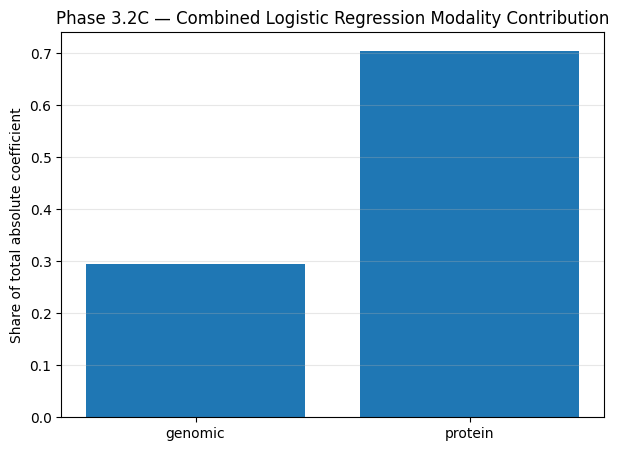

Saved: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/figures/phase3_2C_lr_modality_coefficient_share.png


In [27]:
# ============================================================
# PLOT LR MODALITY CONTRIBUTION
# ============================================================

if combined_lr_model is not None:
    plt.figure(figsize=(7, 5))

    plt.bar(
        modality_coef_summary_df["modality"],
        modality_coef_summary_df["share_of_total_abs_coefficient"]
    )

    plt.ylabel("Share of total absolute coefficient")
    plt.title("Phase 3.2C — Combined Logistic Regression Modality Contribution")
    plt.grid(axis="y", alpha=0.3)

    fig_path = FIGURE_DIR / "phase3_2C_lr_modality_coefficient_share.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

In [28]:
# ============================================================
# WRITE PHASE 3.2 SUMMARY REPORT
# ============================================================

both_correct_n = int((comparison_df["integration_error_group"] == "both_correct").sum())
both_wrong_n = int((comparison_df["integration_error_group"] == "both_wrong").sum())
rescued_n = int((comparison_df["integration_error_group"] == "combined_correct_protein_wrong").sum())
lost_n = int((comparison_df["integration_error_group"] == "protein_correct_combined_wrong").sum())

protein_metrics_row = phase3_2_metric_check_df[
    phase3_2_metric_check_df["model"] == "Protein-only ProtBERT-SW SVM RBF"
].iloc[0]

combined_metrics_row = phase3_2_metric_check_df[
    phase3_2_metric_check_df["model"] == "Combined Protein+Genomic SVM RBF"
].iloc[0]

protein_perm_row = block_permutation_summary_df[
    block_permutation_summary_df["permuted_block"] == "protein_block"
].iloc[0]

genomic_perm_row = block_permutation_summary_df[
    block_permutation_summary_df["permuted_block"] == "genomic_block"
].iloc[0]

lr_summary_text = ""

if combined_lr_model is not None:
    lr_summary_text = f"""
## Interpretable Logistic Regression Coefficient Analysis

A supplementary Combined Logistic Regression model was used for interpretability.

Modality coefficient summary:

{modality_coef_summary_df.to_string(index=False)}

This analysis is supplementary and does not replace the official Combined SVM model.
"""
else:
    lr_summary_text = """
## Interpretable Logistic Regression Coefficient Analysis

Combined Logistic Regression model was not available, so coefficient analysis was skipped.
"""

summary_text = f"""
# Phase 3.2 — Multimodal Error and Modality Contribution Analysis

## Objective

Phase 3.2 analyzed the official multimodal integration result from Phase 3.1.

The analysis focused on:

1. Error comparison between Protein-only SVM and Combined Protein+Genomic SVM.
2. Block permutation importance for protein and genomic feature blocks.
3. Supplementary Logistic Regression coefficient analysis for modality contribution.

## Models Compared

Protein-only model:
- ProtBERT sliding-window embeddings
- SVM RBF
- Threshold: 0.5

Combined model:
- ProtBERT sliding-window embeddings + K3/K4/Basic genomic features
- SVM RBF
- Threshold: 0.5

## Test Performance Comparison

Protein-only SVM:
- ROC-AUC: {protein_metrics_row['roc_auc']:.4f}
- PR-AUC: {protein_metrics_row['pr_auc']:.4f}
- F1: {protein_metrics_row['f1']:.4f}
- MCC: {protein_metrics_row['mcc']:.4f}

Combined SVM:
- ROC-AUC: {combined_metrics_row['roc_auc']:.4f}
- PR-AUC: {combined_metrics_row['pr_auc']:.4f}
- F1: {combined_metrics_row['f1']:.4f}
- MCC: {combined_metrics_row['mcc']:.4f}

## Error Group Analysis

Number of test genes: {len(comparison_df)}

- Both correct: {both_correct_n}
- Both wrong: {both_wrong_n}
- Combined correct, protein wrong: {rescued_n}
- Protein correct, combined wrong: {lost_n}

The 'combined correct, protein wrong' group represents genes rescued by multimodal integration.
The 'protein correct, combined wrong' group represents genes where integration reduced classification correctness.

## Block Permutation Importance

Baseline Combined SVM:
- ROC-AUC: {baseline_combined_metrics['roc_auc']:.4f}
- PR-AUC: {baseline_combined_metrics['pr_auc']:.4f}
- F1: {baseline_combined_metrics['f1']:.4f}
- MCC: {baseline_combined_metrics['mcc']:.4f}

Protein block permutation:
- Mean ROC-AUC drop: {protein_perm_row['mean_roc_auc_drop']:.4f}
- Mean PR-AUC drop: {protein_perm_row['mean_pr_auc_drop']:.4f}
- Mean F1 drop: {protein_perm_row['mean_f1_drop']:.4f}
- Mean MCC drop: {protein_perm_row['mean_mcc_drop']:.4f}

Genomic block permutation:
- Mean ROC-AUC drop: {genomic_perm_row['mean_roc_auc_drop']:.4f}
- Mean PR-AUC drop: {genomic_perm_row['mean_pr_auc_drop']:.4f}
- Mean F1 drop: {genomic_perm_row['mean_f1_drop']:.4f}
- Mean MCC drop: {genomic_perm_row['mean_mcc_drop']:.4f}

Interpretation:
- A larger drop after permuting a block indicates stronger dependence on that modality.
- If both protein and genomic block permutation reduce performance, the combined model uses both modalities.
- If only protein permutation strongly reduces performance, the combined model is mostly protein-driven.

{lr_summary_text}

## Conclusion

Phase 3.2 provides interpretability evidence for the multimodal result.

The key question is whether the combined model improves ranking and whether the genomic block contributes beyond protein embeddings.

This analysis should be used to support the final Phase 3 report and decide whether further integration methods such as PCA integration, late fusion, or DNABERT embeddings are needed.
"""

summary_path = REPORT_DIR / "phase3_2_error_modality_contribution_summary.md"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


# Phase 3.2 — Multimodal Error and Modality Contribution Analysis

## Objective

Phase 3.2 analyzed the official multimodal integration result from Phase 3.1.

The analysis focused on:

1. Error comparison between Protein-only SVM and Combined Protein+Genomic SVM.
2. Block permutation importance for protein and genomic feature blocks.
3. Supplementary Logistic Regression coefficient analysis for modality contribution.

## Models Compared

Protein-only model:
- ProtBERT sliding-window embeddings
- SVM RBF
- Threshold: 0.5

Combined model:
- ProtBERT sliding-window embeddings + K3/K4/Basic genomic features
- SVM RBF
- Threshold: 0.5

## Test Performance Comparison

Protein-only SVM:
- ROC-AUC: 0.7274
- PR-AUC: 0.7433
- F1: 0.6667
- MCC: 0.3215

Combined SVM:
- ROC-AUC: 0.7290
- PR-AUC: 0.7573
- F1: 0.6590
- MCC: 0.3438

## Error Group Analysis

Number of test genes: 271

- Both correct: 164
- Both wrong: 74
- Combined correct, protein wrong: 18
- Protein correct, combined wrong: 15

The

In [29]:
display(phase3_2_metric_check_df)
display(error_group_counts_df)
display(error_group_by_label_df)
display(score_delta_summary_df)
display(block_permutation_summary_df)

if combined_lr_model is not None:
    display(modality_coef_summary_df)
    display(top_genomic_coef_df.head(20))

,model,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Protein-only ProtBERT-SW SVM RBF,0.5,0.660517,0.652482,0.681481,0.639706,0.666667,0.727397,0.743341,0.321450,87,49,43,92
1,Combined Protein+Genomic SVM RBF,0.5,0.671587,0.682540,0.637037,0.705882,0.659004,0.728976,0.757253,0.343763,96,40,49,86


,integration_error_group,n,percentage
0,both_correct,164,60.516605
1,both_wrong,74,27.306273
2,combined_correct_protein_wrong,18,6.642066
3,protein_correct_combined_wrong,15,5.535055


true_label,0,1,All
integration_error_group,,,
both_correct,81,83,164
both_wrong,34,40,74
combined_correct_protein_wrong,15,3,18
protein_correct_combined_wrong,6,9,15
All,136,135,271


,integration_error_group,n,mean_protein_score,mean_combined_score,mean_delta_combined_minus_protein,median_delta_combined_minus_protein
0,both_correct,164,0.498823,0.501418,0.002595,-0.001121
1,both_wrong,74,0.465782,0.471258,0.005476,0.004681
2,combined_correct_protein_wrong,18,0.558602,0.447129,-0.111474,-0.114755
3,protein_correct_combined_wrong,15,0.522147,0.495538,-0.026609,-0.024624


,permuted_block,n_repeats,baseline_roc_auc,baseline_pr_auc,baseline_f1,baseline_mcc,mean_roc_auc_after_permutation,std_roc_auc_after_permutation,mean_roc_auc_drop,std_roc_auc_drop,mean_pr_auc_after_permutation,std_pr_auc_after_permutation,mean_pr_auc_drop,std_pr_auc_drop,mean_f1_after_permutation,std_f1_after_permutation,mean_f1_drop,std_f1_drop,mean_mcc_after_permutation,std_mcc_after_permutation,mean_mcc_drop,std_mcc_drop
1,protein_block,30,0.728976,0.757253,0.659004,0.343763,0.530081,0.039645,0.198895,0.039645,0.532956,0.031624,0.224297,0.031624,0.511347,0.035914,0.147657,0.035914,0.035364,0.067592,0.308399,0.067592
0,genomic_block,30,0.728976,0.757253,0.659004,0.343763,0.706920,0.015688,0.022056,0.015688,0.717830,0.023151,0.039423,0.023151,0.651617,0.019692,0.007387,0.019692,0.314582,0.038780,0.029181,0.038780


,modality,n_features,sum_abs_coefficient,mean_abs_coefficient,median_abs_coefficient,max_abs_coefficient,share_of_total_abs_coefficient
0,genomic,355,2.773525,0.007813,0.006411,0.036489,0.295401
1,protein,1024,6.615487,0.006460,0.005430,0.031693,0.704599


,feature,coefficient,abs_coefficient,modality
1301,k4_GTAG,-0.036489,0.036489,genomic
1295,k4_GGTA,-0.027391,0.027391,genomic
1143,k4_ACCA,-0.026827,0.026827,genomic
1345,k4_TCTG,-0.026394,0.026394,genomic
1246,k4_CTGT,-0.025098,0.025098,genomic
1211,k4_CCGA,-0.024708,0.024708,genomic
1206,k4_CCAT,-0.024556,0.024556,genomic
1348,k4_TGAC,0.023761,0.023761,genomic
1176,k4_ATCC,-0.023738,0.023738,genomic
1220,k4_CGAC,-0.022881,0.022881,genomic
